🚀 [7/7] LightGBM 訓練開始...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Accuracy: 0.6743
                  precision    recall  f1-score   support

      feel_angry       0.60      0.69      0.64       635
     feel_boring       0.53      0.84      0.65       285
 feel_depressing       0.68      0.88      0.77       320
      feel_happy       0.63      0.57      0.60       978
feel_informative       0.81      0.61      0.70      1979
        feel_odd       0.56      0.82      0.67       295
       feel_warm       0.66      0.94      0.77       181
    feel_worried       0.73      0.93      0.82        55

        accuracy                           0.67      4728
       macro avg       0.65      0.79      0.70      4728
    weighted avg       0.70      0.67      0.67      4728



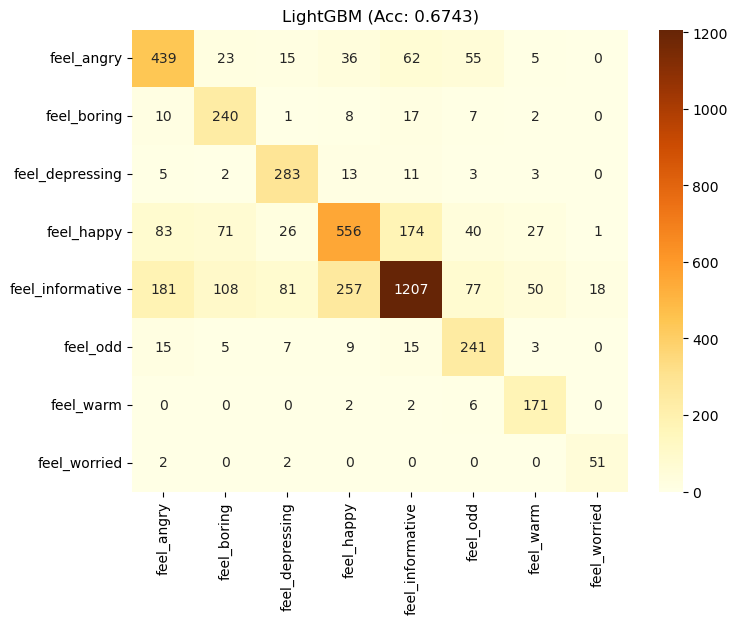

In [1]:
# 7_LightGBM.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

if __name__ == '__main__':
    print("🚀 [7/7] LightGBM 訓練開始...")
    
    df = pd.read_csv('Processed_Data.csv')
    df['text_segmented'] = df['text_segmented'].fillna('')
    X_text = df['text_segmented'].values
    y_raw = df['Column1'].values

    vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), min_df=3, sublinear_tf=True, dtype=np.float32)
    X_tfidf = vectorizer.fit_transform(X_text)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(X_tfidf))
    X_train, X_test = X_tfidf[train_idx], X_tfidf[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    # n_jobs=6 安全
    model = LGBMClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        n_jobs=6, 
        force_col_wise=True, 
        verbose=-1, 
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'LightGBM (Acc: {acc:.4f})')
    plt.show()